## Following Approch to Predict Does The Person Has Heart Disease Or Not :
* Problem Definiction
* Data
  
*https://archive.ics.uci.edu/dataset/45/heart+disease*
* Evaluation
* Features
* Modeling
* Expermination

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression   
from sklearn.neighbors import KNeighborsClassifier   

In [3]:
from sklearn.model_selection import train_test_split, cross_val_score,RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import f1_score,precision_score, recall_score
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

In [4]:
data_set = pd.read_csv('C:\\Users\\shaik\\PycharmProjects\\ML learning\\data sets\\heart-disease.csv')

In [5]:
data_set.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [6]:
data_set['sex'].value_counts()

sex
1    207
0     96
Name: count, dtype: int64

In [7]:
pd.crosstab(data_set.target, data_set.sex)

sex,0,1
target,,
0,24,114
1,72,93


In [8]:
data_set.groupby(['sex', 'target']).size()

sex  target
0    0          24
     1          72
1    0         114
     1          93
dtype: int64

In [9]:
data_set.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


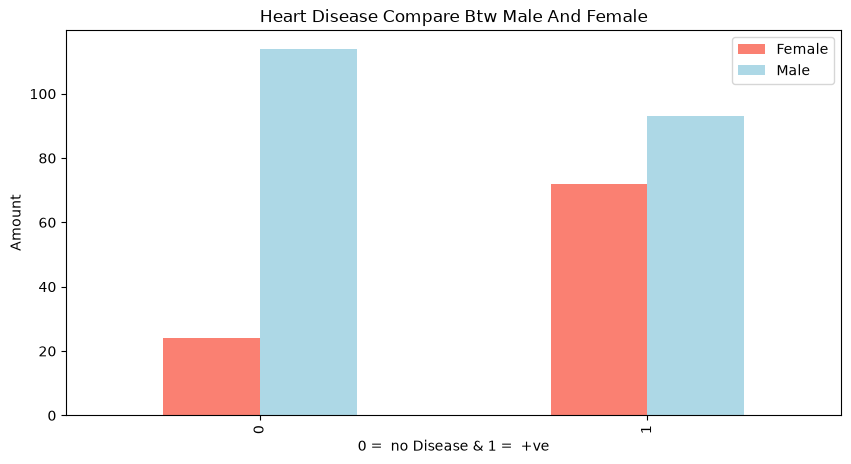

In [10]:
pd.crosstab(data_set.target, data_set.sex).plot(kind = 'bar', figsize = (10,5), color = ['salmon', 'lightblue'])
plt.title('Heart Disease Compare Btw Male And Female')
plt.xlabel('0 =  no Disease & 1 =  +ve')
plt.ylabel('Amount')
plt.legend(['Female', 'Male']);

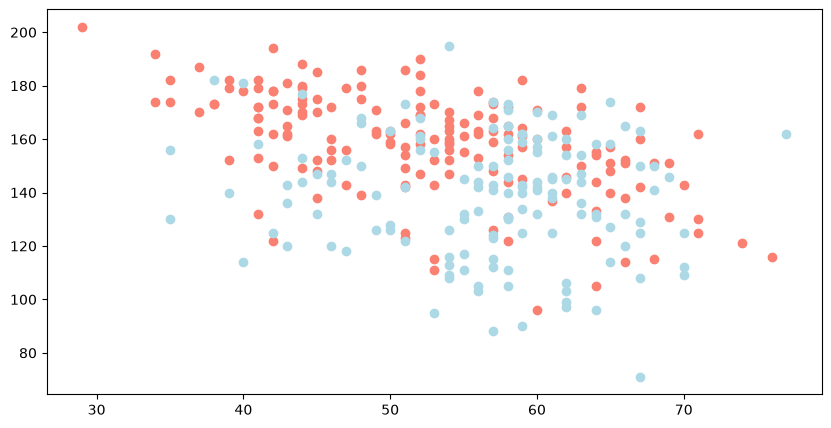

In [11]:
plt.figure(figsize = (10,5))
plt.scatter(data_set.age[data_set.target == 1],
           data_set.thalach[data_set.target == 1],  c= 'salmon')

plt.scatter(data_set.age[data_set.target == 0],
           data_set.thalach[data_set.target == 0],
           c = 'lightblue');


In [12]:
age_disease = data_set.loc[(data_set['thal'] == 1)]

In [13]:
age_disease

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
62,52,1,3,118,186,0,0,190,0,0.0,1,0,1,1
63,41,1,1,135,203,0,1,132,0,0.0,1,0,1,1
138,57,1,0,110,201,0,1,126,1,1.5,1,0,1,1
150,66,1,0,160,228,0,0,138,0,2.3,2,0,1,1
170,56,1,2,130,256,1,0,142,1,0.6,1,1,1,0
179,57,1,0,150,276,0,0,112,1,0.6,1,1,1,0
199,65,1,0,110,248,0,0,158,0,0.6,2,2,1,0
242,64,1,0,145,212,0,0,132,0,2.0,1,2,1,0


In [14]:
data_set['thalach'].value_counts()

thalach
162    11
160     9
163     9
152     8
173     8
       ..
202     1
184     1
121     1
192     1
90      1
Name: count, Length: 91, dtype: int64

In [15]:
data_set.loc[(data_set['target'] == 1) & (data_set['thalach'] == data_set['thalach'].max())]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
72,29,1,1,130,204,0,0,202,0,0.0,2,0,2,1


In [16]:
data_set.loc[(data_set['target'] == 0 ) & (data_set['thalach'] == data_set['thalach'].min())]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
272,67,1,0,120,237,0,1,71,0,1.0,1,0,2,0


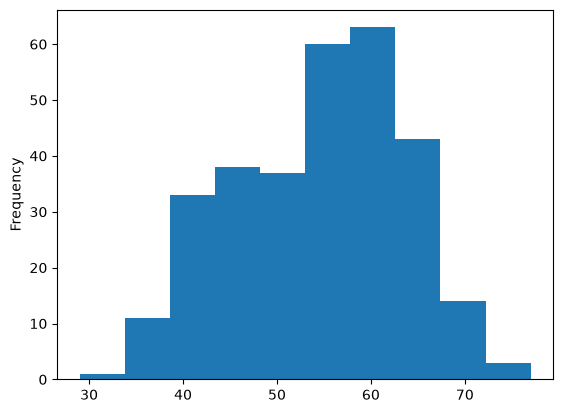

In [17]:
data_set.age.plot.hist();

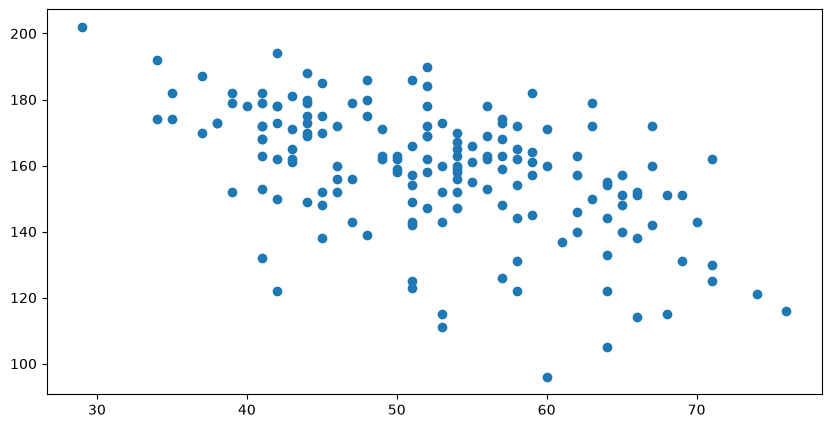

In [18]:
plt.figure(figsize = (10,5))
plt.scatter(data_set.age[data_set.target == 1],
           data_set.thalach[data_set.target == 1])

In [19]:
pd.crosstab(data_set['cp'], data_set['target'])

target,0,1
cp,,
0,104,39
1,9,41
2,18,69
3,7,16


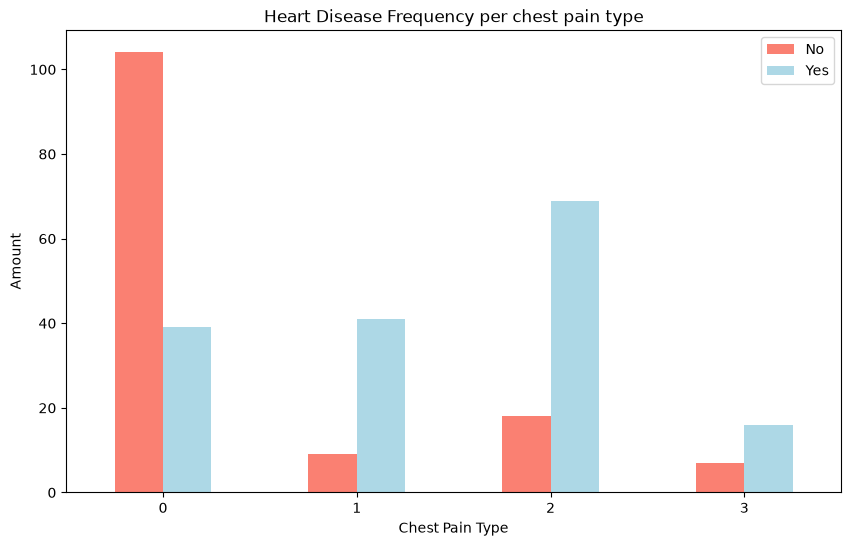

In [20]:
pd.crosstab(data_set['cp'], data_set['target']).plot(kind = 'bar', 
                                                     figsize = (10,6),
                                                    color = ['salmon', 'lightblue'])
plt.title('Heart Disease Frequency per chest pain type')
plt.xlabel('Chest Pain Type')
plt.ylabel('Amount')
plt.legend(['No', 'Yes'])
plt.xticks(rotation = 0 );

<Axes: ylabel='cp'>

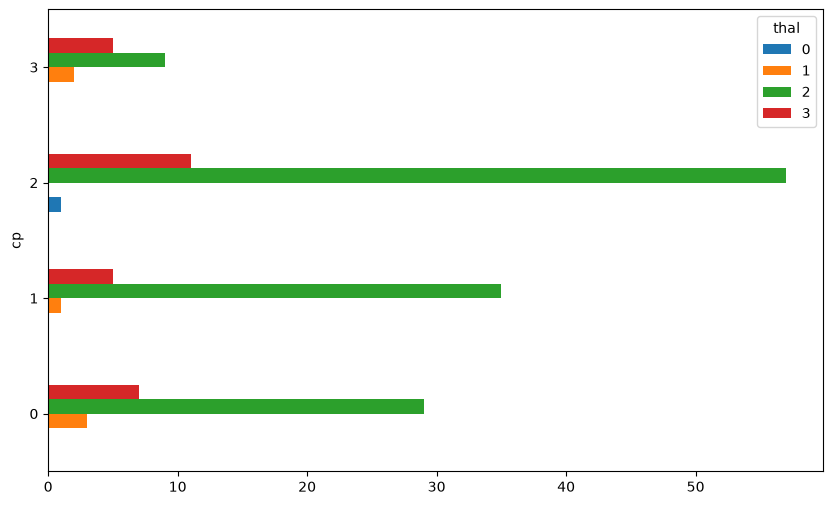

In [21]:
pd.crosstab(data_set.cp[data_set.target == 1],
           data_set.thal[data_set.target == 1]).plot(kind = 'barh', 
                                                    figsize = (10,6),
                                                    )

In [22]:
from sklearn.model_selection import train_test_split
X = data_set.drop('target', axis = 1)
y = data_set['target']
X_train,X_test,y_train,y_test = train_test_split(X, y)

In [26]:
clf = {
    'RandomForest':RandomForestClassifier(),
    'KNeighbors':KNeighborsClassifier(),
    'LogisticRegression':LogisticRegression()
}

Randomgrid = {
    'n_estimators':[100,150,200],
    'criterion':["gini", "entropy", "log_loss"],
    'max_depth':[10,15],
    'min_samples_split':[2],
    'min_samples_leaf':[2,4],
    'max_features':["sqrt", "log2", None]
}
loggrid = {
    'penalty':['l2', None],
    'dual':[True],
    'fit_intercept':[True]
}

kgrid = {
    'n_neighbors':[5,10],
    'weights':['uniform','distance'],
    'algorithm':['auto','ball_tree', 'kd_tree', 'brute'],
    'leaf_size':[30],
    'p':[2],
    'metric':['minkowski']
}
grid_names = {
    'RandomForest':Randomgrid,
    'KNeighbors':kgrid,
    'LogisticRegression':loggrid
}

In [27]:
for name, model in clf.items():
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    print(f'{name}: {score*100:.2f}%')

RandomForest: 88.16%
KNeighbors: 67.11%
LogisticRegression: 88.16%


C:\Users\shaik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [28]:
for name, model in clf.items():
    g_model = RandomizedSearchCV(estimator = model, param_distributions = grid_names[name])
    g_model.fit(X_train, y_train)
    score = g_model.score(X_test, y_test)
    print(f'{name}: {score * 100 :.2f}')

RandomForest: 88.16
KNeighbors: 69.74


C:\Users\shaik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 2 is smaller than n_iter=10. Running 2 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
C:\Users\shaik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\shaik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalt

ValueError: 
All the 10 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\shaik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\shaik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\shaik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py", line 1416, in fit
    solver = _check_solver(self.solver, penalty, self.dual)
             ^^^^^^^^^^^^^^^^^^